# Análisis Biomecánico del Saque de Tenis: Stance y Fases
**Trabajo de Fin de Grado - BioServe**

Este notebook procesa los datos crudos de MediaPipe para:
1.  Detectar las fases temporales del saque (Inicio, Carga, Target, Extensión).
2.  Extraer métricas clave (Arrastre de tobillo, Ángulos de rodilla).
3.  Generar visualizaciones validadas para la memoria del TFG.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

# --- CONFIGURACIÓN GLOBAL ---
# Ruta a los archivos CSV procesados
CSV_FOLDER = Path(r"C:\Users\david\Desktop\Results\datos_csv") 

# Listado automático de archivos
all_files = sorted(list(CSV_FOLDER.glob('*.csv')))

print(f"✅ Configuración cargada. Se han encontrado {len(all_files)} archivos.")

✅ Configuración cargada. Se han encontrado 109 archivos.


In [2]:
def calculate_angle(a, b, c):
    """
    Calcula el ángulo en grados entre 3 puntos (A-B-C), siendo B el vértice.
    Usa el producto escalar de vectores.
    """
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0: return 0.0
    
    cosine = np.dot(ba, bc) / denom
    angle = np.arccos(np.clip(cosine, -1.0, 1.0))
    return np.degrees(angle)

def calculate_distance(p1, p2):
    """Calcula la distancia euclidiana entre dos puntos (x, y)."""
    return np.linalg.norm(np.array(p1) - np.array(p2))

In [3]:
def detectar_fases_saque(angulos, max_dist_frames=200):
    """
    Identifica los hitos temporales del saque basándose en la topología de la señal.
    
    Args:
        angulos (list): Lista de ángulos de flexión de rodilla.
        max_dist_frames (int): Distancia máxima permitida entre carga y extensión.
        
    Returns:
        tuple: (start_frame, min_frame, max_frame, target_frame)
               Inicio (Morado), Carga (Rojo), Extensión (Verde), Target (Amarillo)
    """
    data = np.array(angulos)
    
    # 1. Búsqueda de Candidatos (Picos y Valles)
    picos_idx, _ = find_peaks(data, height=150, distance=20)   # Extensión
    valles_idx, _ = find_peaks(-data, height=-165, distance=20) # Flexión
    
    # 2. Selección de la Mejor Pareja (Mayor Rango Ascendente)
    best_score, best_min, best_max = -1, -1, -1
    
    for valle in valles_idx:
        for pico in picos_idx:
            # Lógica temporal: Valle debe ir antes que Pico
            if valle < pico:
                if (pico - valle) < max_dist_frames:
                    recorrido = data[pico] - data[valle]
                    # Maximizamos la subida (ROM)
                    if recorrido > best_score:
                        best_score = recorrido
                        best_min = valle
                        best_max = pico
    
    # Fallback de seguridad
    if best_min == -1: 
        best_min, best_max = np.argmin(data), np.argmax(data)
        
    # 3. Refinamiento del Mínimo (Lupa local)
    ventana = 10
    ini, end = max(0, best_min - ventana), min(len(data), best_min + ventana)
    best_min = ini + np.argmin(data[ini:end])
    
    # 4. Cálculo del Target Frame (Factor 0.325)
    # Punto de máxima inercia antes del despegue
    target = int(best_min + (best_max - best_min) * 0.325)
    
    # 5. Búsqueda del Inicio (Punto Morado)
    # Miramos hacia atrás buscando la posición erguida previa
    s_search = max(0, best_min - 150)
    pre_data = data[s_search:best_min]
    start = s_search + np.argmax(pre_data) if len(pre_data) > 0 else 0
    
    return start, best_min, best_max, target

In [4]:
# Seleccionamos una muestra balanceada para visualizar (4 Pinpoint + 4 Platform)
pinpoint_files = [f for f in all_files if "pinpoint" in f.name.lower()][:6]
platform_files = [f for f in all_files if "platform" in f.name.lower()][:6]
seleccionados = pinpoint_files + platform_files

print(f"🔬 Muestra de validación seleccionada: {len(seleccionados)} videos.")

🔬 Muestra de validación seleccionada: 12 videos.


# PROCESAMOS LOS BUCLES DE VISUALIZACION

**Visualización de los angulos de rodilla con pinpoint o platform**

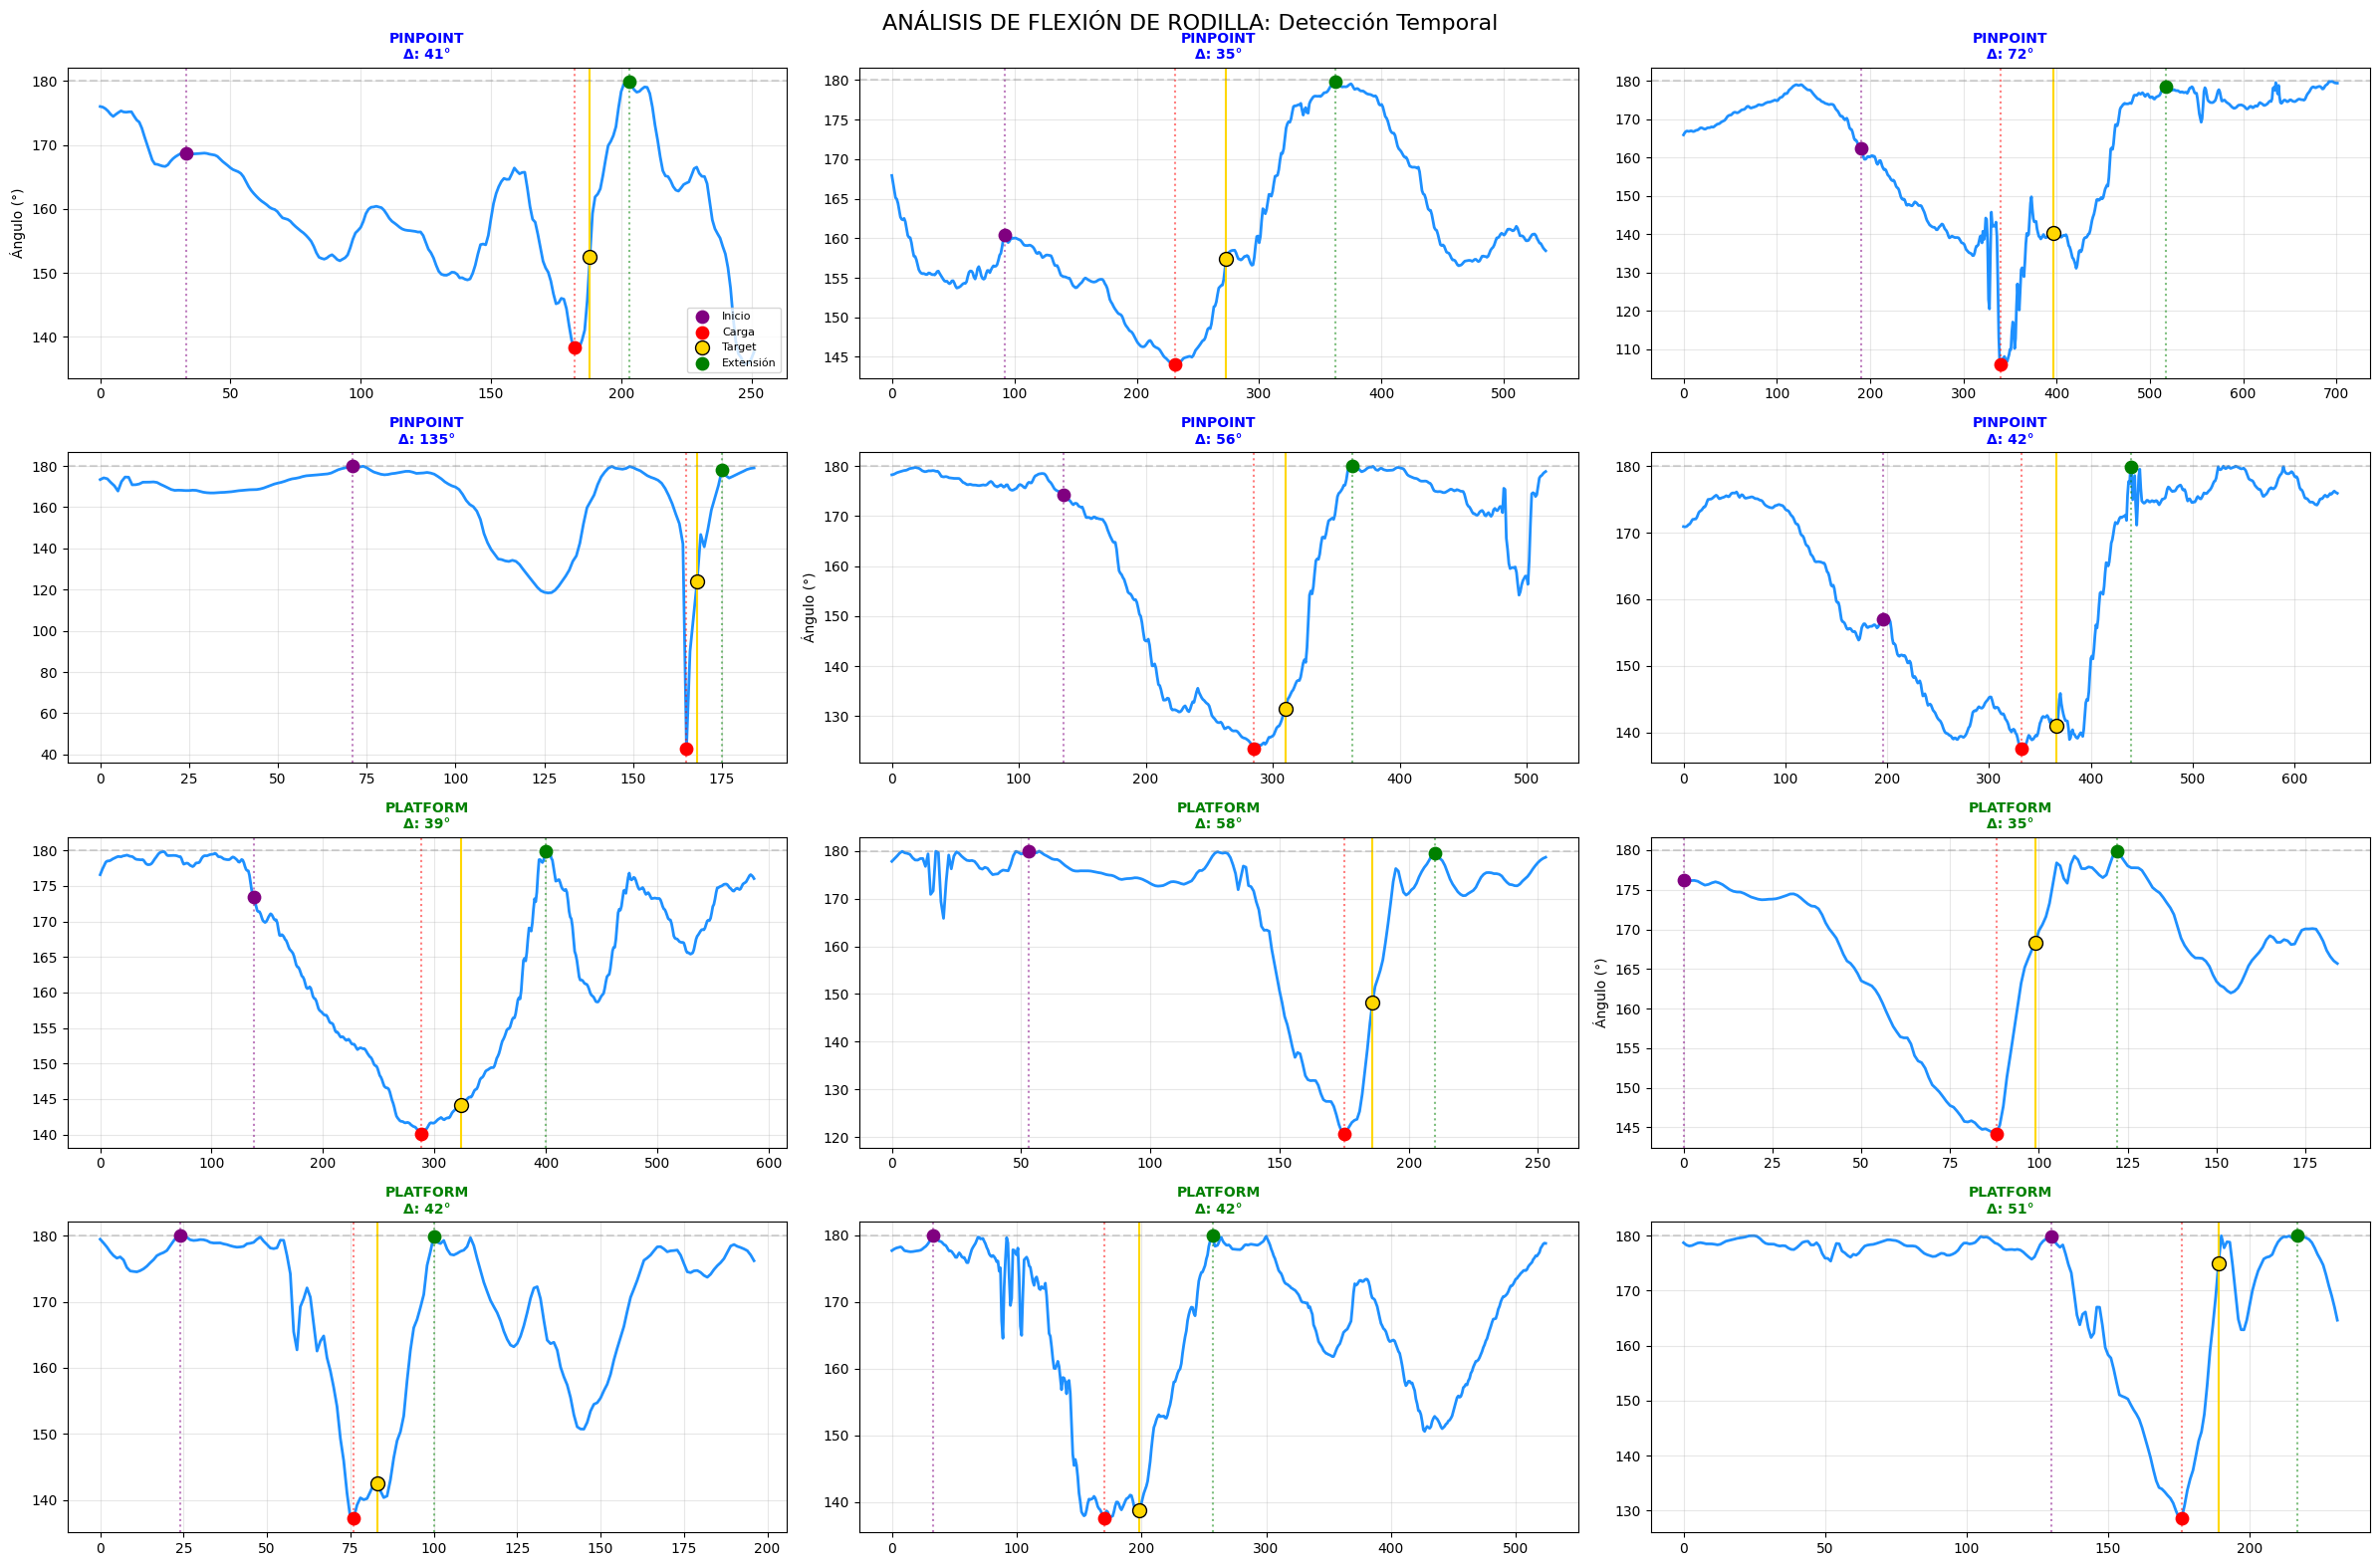

In [5]:
# --- BUCLE 1: VALIDACIÓN DE FASES (RODILLA) ---

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24, 16))
axes = axes.flatten() 

for idx, file_path in enumerate(seleccionados):
    try:
        df = pd.read_csv(file_path)
        
        # 1. Calcular Ángulos
        angulos_izquierda = []
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))
        
        df['angulo'] = angulos_izquierda
        
        # 2. Detectar Fases
        start, min_f, max_f, target_f = detectar_fases_saque(df['angulo'])
        
        # Extraer valores para pintar
        start_val = df.loc[start, 'angulo']
        min_val = df.loc[min_f, 'angulo']
        max_val = df.loc[max_f, 'angulo']
        target_val = df.loc[target_f, 'angulo']
        
        # 3. Pintar Gráfica
        ax = axes[idx]
        
        tipo = "PINPOINT" if "pinpoint" in file_path.name.lower() else "PLATFORM"
        color_titulo = "blue" if tipo == "PINPOINT" else "green"
        
        # Línea de ángulo
        ax.plot(df['frame_id'], df['angulo'], color='dodgerblue', linewidth=2)
        
        # Puntos Clave
        ax.scatter(df.loc[start, 'frame_id'], start_val, color='purple', s=80, zorder=5, label='Inicio')
        ax.scatter(df.loc[min_f, 'frame_id'], min_val, color='red', s=80, zorder=5, label='Carga')
        ax.scatter(df.loc[target_f, 'frame_id'], target_val, color='gold', s=100, edgecolor='black', zorder=10, label='Target')
        ax.scatter(df.loc[max_f, 'frame_id'], max_val, color='green', s=80, zorder=5, label='Extensión')

        # Líneas Verticales
        ax.axvline(x=df.loc[start, 'frame_id'], color='purple', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[min_f, 'frame_id'], color='red', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[target_f, 'frame_id'], color='gold', linestyle='-', linewidth=1.5)
        ax.axvline(x=df.loc[max_f, 'frame_id'], color='green', linestyle=':', alpha=0.5)
        
        # Título y Decoración
        subida = int(max_val - min_val)
        ax.set_title(f"{tipo}\nΔ: {subida}°", fontsize=10, color=color_titulo, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=180, color='gray', linestyle='--', alpha=0.3)
        
        # Etiquetas solo en bordes
        if idx % 4 == 0: ax.set_ylabel("Ángulo (°)")
        if idx >= 12: ax.set_xlabel("Frame")
        
        # Leyenda solo en el primero
        if idx == 0: ax.legend(loc='lower right', fontsize=8)

    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("ANÁLISIS DE FLEXIÓN DE RODILLA: Detección Temporal", fontsize=16)
plt.tight_layout()
plt.show()

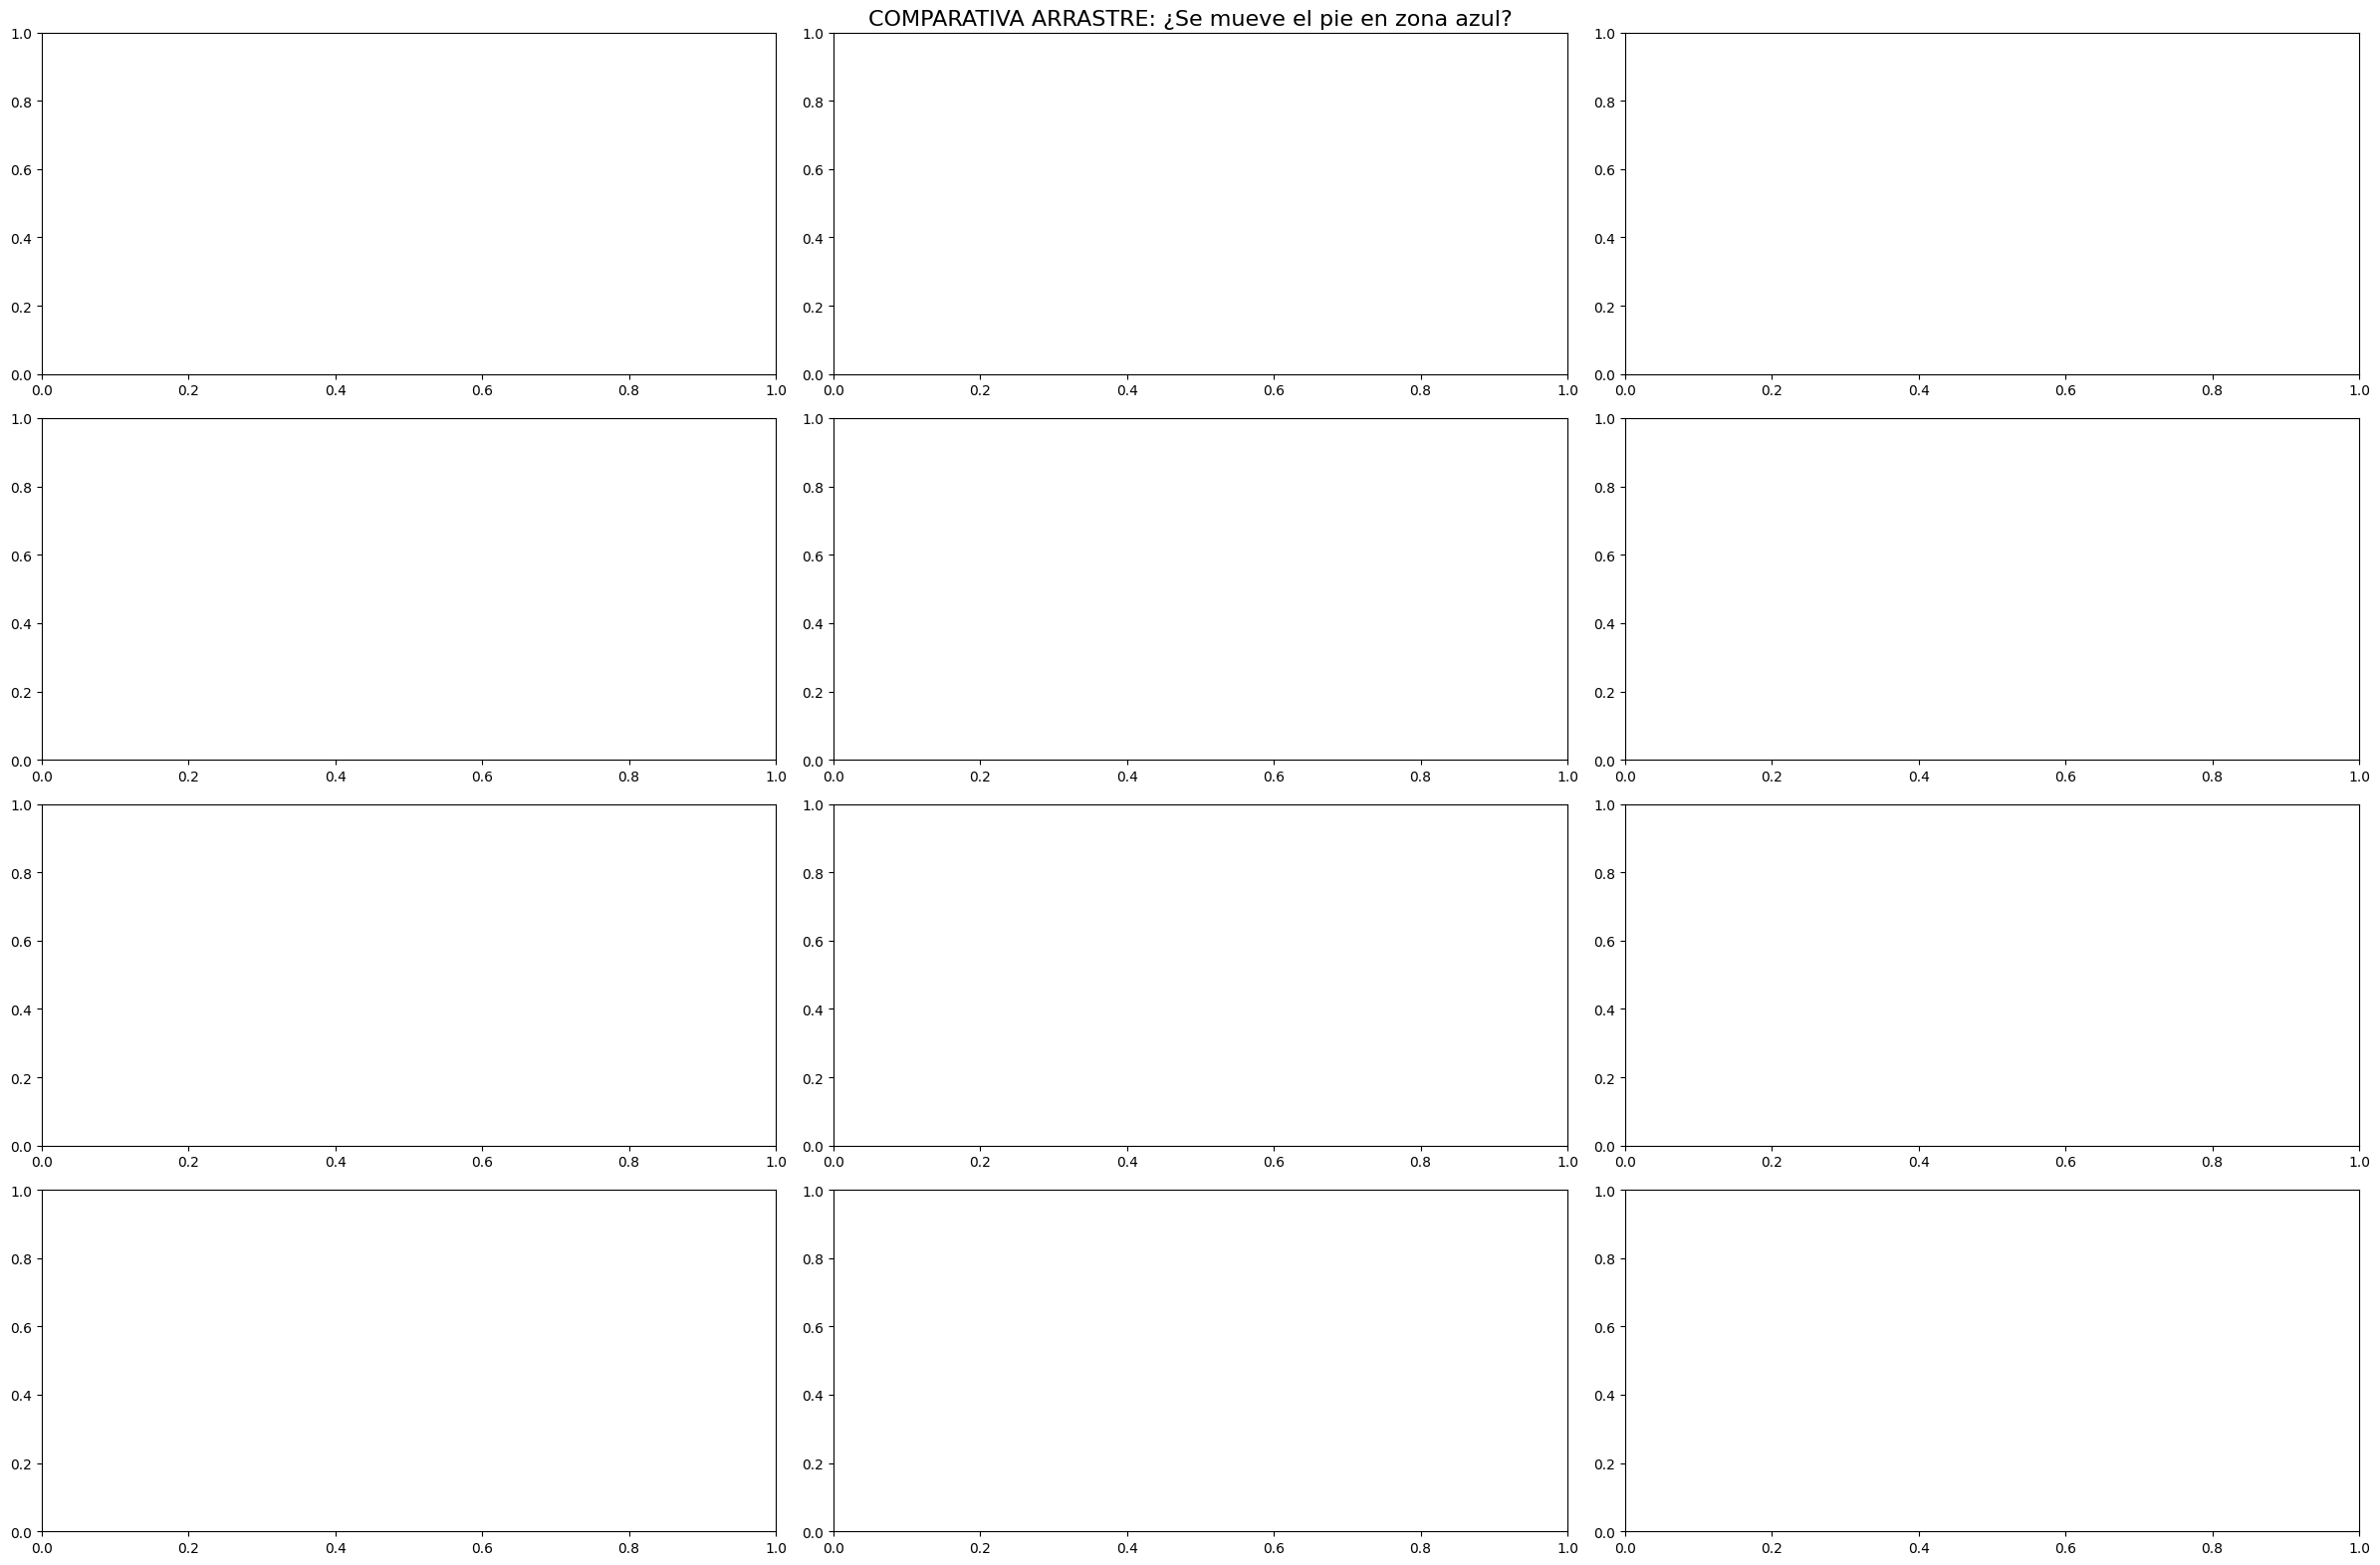

In [6]:
# --- BUCLE 2: VALIDACIÓN DE ARRASTRE (VELOCIDAD TOBILLO) ---

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24, 16)) # Grid 4x4
axes = axes.flatten() 

for idx, file_path in enumerate(seleccionados):
    try:
        df = pd.read_csv(file_path)
        
        # A. PREPARAR DATOS
        angulos_izquierda = []
        velocidades_tobillo = [0] 
        
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))
            
            # Velocidad Tobillo Derecho
            if i > 0:
                curr_ankle = np.array([df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']])
                prev_ankle = np.array([df.loc[i-1, 'RIGHT_ANKLE_x'], df.loc[i-1, 'RIGHT_ANKLE_y']])
                
                # Normalización
                r_hip = np.array([df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']])
                l_hip_curr = np.array([df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']])
                width_hip = np.linalg.norm(r_hip - l_hip_curr)
                
                dist_pixels = np.linalg.norm(curr_ankle - prev_ankle)
                # Evitar división por cero
                velocidad = dist_pixels / width_hip if width_hip > 0 else 0
                velocidades_tobillo.append(velocidad)
        
        df['angulo'] = angulos_izquierda
        # Suavizado para ver mejor la tendencia
        df['velocidad_tobillo'] = pd.Series(velocidades_tobillo).rolling(window=3).mean().fillna(0)
        
        # B. DETECTAR FASES
        start, min_f, max_f, target_f = detectar_fases_saque(df['angulo'])
        
        # C. PINTAR GRÁFICA
        
        
        tipo = "PINPOINT" if "pinpoint" in file_path.name.lower() else "PLATFORM"
        color_titulo = "blue" if tipo == "PINPOINT" else "brown"
        
        ax.plot(df['frame_id'], df['velocidad_tobillo'], color='black', linewidth=1.5)
        
        # Zona de Arrastre (Sombreado Azul)
        ax.fill_between(df['frame_id'], df['velocidad_tobillo'], 
                        where=(df['frame_id'] >= start) & (df['frame_id'] <= target_f), 
                        color='skyblue', alpha=0.4)

        # Líneas Verticales
        ax.axvline(x=df.loc[start, 'frame_id'], color='purple', linestyle='--', linewidth=2) # Inicio
        ax.axvline(x=df.loc[min_f, 'frame_id'], color='red', linestyle='--', linewidth=2)    # Carga
        ax.axvline(x=df.loc[target_f, 'frame_id'], color='gold', linestyle='-', linewidth=3) # Target
        ax.axvline(x=df.loc[max_f, 'frame_id'], color='green', linestyle='--', linewidth=2)  # Extensión
        
        ax.set_title(f"{tipo}\n{file_path.stem[:15]}...", fontsize=9, color=color_titulo, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Etiquetas solo en bordes
        if idx % 4 == 0: ax.set_ylabel("Velocidad")
        if idx >= 12: ax.set_xlabel("Frame")

    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("COMPARATIVA ARRASTRE: ¿Se mueve el pie en zona azul?", fontsize=16)
plt.tight_layout()
plt.show()

# DESPUES DEL ESTUDIO VAMOS A SACAR EL TRAIN_CSV

In [7]:
dataset_rows = []
bad_files = 0

print(f"procesando {len(all_files)} videos.")

for file_path in all_files:
    try:
        df = pd.read_csv(file_path)
        
        # --- 1. CALCULAR ÁNGULOS DE RODILLA IZQUIERDA---
        angulos = []
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos.append(calculate_angle(l_hip, l_knee, l_ankle))
            
        # --- 2. DETECTAR FASES SAQUE---
        start, min_f, max_f, target_f = detectar_fases_saque(angulos)
        
        # Guardamos el frame de los valores de rodilla
        
        angle_start = angulos[start]   # Morado
        angle_min = angulos[min_f]       # Rojo
        angle_target = angulos[target_f] # Amarillo
        
        # Filtro de Calidad, si la rodilla baja de 45º, es un error de Mediapipe. Descartamos
        if angle_min< 45:
            print(f"Descarte: {file_path.name} (Ángulo de rodilla imposible)")
            bad_files += 1
            continue
        
        # --- 3. METRICAS ---
        
        # Feature 1: ARRASTRE ACUMULADO, Sumamos la distancia que recorre el pie frame a frame desde Start hasta Target
        acumulated_drag_pixels = 0
        for i in range(start, target_f):
            current_ank = np.array([df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']])
            next_ank = np.array([df.loc[i+1, 'RIGHT_ANKLE_x'], df.loc[i+1, 'RIGHT_ANKLE_y']])
            acumulated_drag_pixels += np.linalg.norm(next_ank - current_ank)
        
        # Normalizacion con el ancho de cadera en el Target       
        hip_r = np.array([df.loc[target_f, 'RIGHT_HIP_x'], df.loc[target_f, 'RIGHT_HIP_y']])
        hip_l = np.array([df.loc[target_f, 'LEFT_HIP_x'], df.loc[target_f, 'LEFT_HIP_y']])
        hip_width = np.linalg.norm(hip_r - hip_l)
        
        # Arrastre final normalizado
        ankle_drag = acumulated_drag_pixels/hip_width if hip_width > 0 else 0
        
        
        # FEATURE 2 INCLINACIÓN CADERA (HIP TILT)
        hip_tilt = abs(hip_l[1] - hip_r[1]) / hip_width if hip_width > 0 else 0
        
        
        # --- 4. ETIQUETADO ---
        name = file_path.name.lower()
        if "pinpoint" in name: label = 0
        elif "platform" in name: label = 1
        else: label = -1

        if label != -1:
            dataset_rows.append({
                "Video_ID": file_path.name,
                "Ankle_Drag": round(ankle_drag, 4),
                "Knee_Start": round(angle_start, 2),
                "Knee_Min": round(angle_min, 2),
                "Knee_Target": round(angle_target, 2),
                "Hip_Tilt": round(hip_tilt, 4),
                "Stance_Label": label
            })
        
    except Exception as e:
        print(f"Error en {file_path.name}: {e}")


# --- GUARDAR RESULTADO ---
train_df = pd.DataFrame(dataset_rows)
output_csv = "train.csv"
train_df.to_csv(output_csv, index=False)

print(f"DATASET GENERADO: {output_csv}\n")
print(f"Total de muestras: {len(train_df)}\n")

train_df.head()

procesando 109 videos.
Descarte: flat_pinpoint_114_landmarks.csv (Ángulo de rodilla imposible)
Descarte: flat_pinpoint_67_landmarks.csv (Ángulo de rodilla imposible)
Descarte: kick_platform_49_landmarks.csv (Ángulo de rodilla imposible)
Descarte: slice_pinpoint_117_landmarks.csv (Ángulo de rodilla imposible)
Descarte: slice_pinpoint_123_landmarks.csv (Ángulo de rodilla imposible)
DATASET GENERADO: train.csv

Total de muestras: 104



,Video_ID,Ankle_Drag,Knee_Start,Knee_Min,Knee_Target,Hip_Tilt,Stance_Label
0,flat_pinpoint_103_landmarks.csv,25.0840,168.74,138.30,152.53,1.0000,0
1,flat_pinpoint_107_landmarks.csv,2.0281,160.42,144.11,157.38,0.6861,0
2,flat_pinpoint_113_landmarks.csv,28.2208,162.51,106.18,140.36,0.5855,0
3,flat_pinpoint_115_landmarks.csv,6.3603,174.32,123.50,131.55,0.8439,0
4,flat_pinpoint_116_landmarks.csv,17.1229,156.98,137.55,140.96,0.6289,0


✅ Dataset cargado: 104 muestras.
🦵 Ángulo mínimo de rodilla encontrado: 60.04°
✨ ¡PERFECTO! No hay rodillas rotas (Outliers eliminados).


<Figure size 800x500 with 0 Axes>

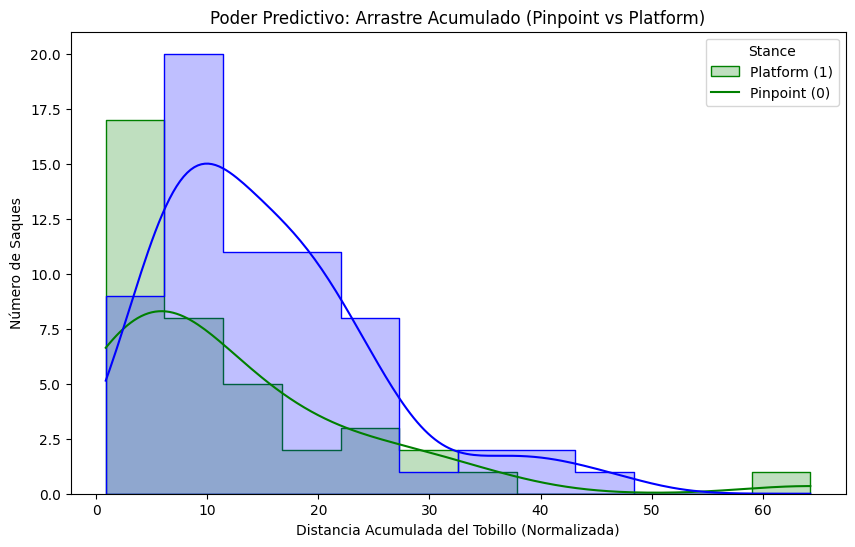

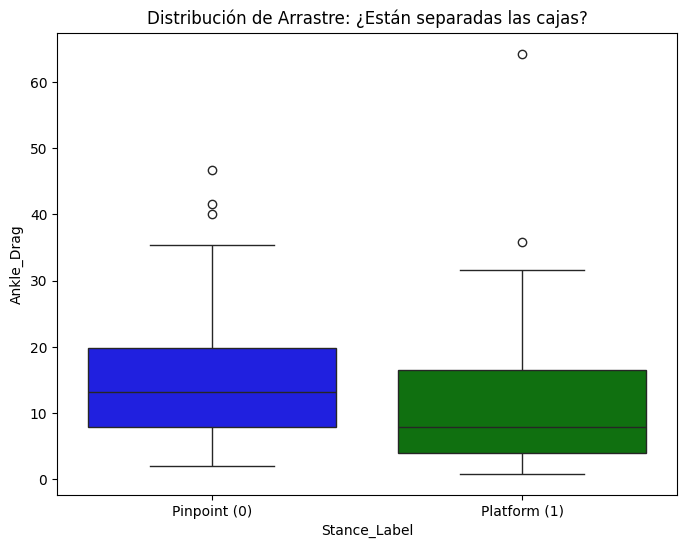

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 5))

# 1. Cargar datos
df_final = pd.read_csv("train.csv")
print(f"✅ Dataset cargado: {len(df_final)} muestras.")

# --- LA SOLUCIÓN AL ERROR ---
# Convertimos la columna a TEXTO para que coincida con la paleta con comillas
df_final['Stance_Label'] = df_final['Stance_Label'].astype(str)
# -----------------------------

# 2. COMPROBACIÓN DE SEGURIDAD (Rodillas)
min_knee = df_final['Knee_Min'].min()
print(f"🦵 Ángulo mínimo de rodilla encontrado: {min_knee}°")

if min_knee > 45:
    print("✨ ¡PERFECTO! No hay rodillas rotas (Outliers eliminados).")
else:
    print(f"⚠️ CUIDADO: Todavía hay valores bajos ({min_knee}°). Revisa el filtro.")

# 3. GRÁFICA 1: HISTOGRAMA (Poder Predictivo)
plt.figure(figsize=(10, 6))
# Nota: Ahora usamos comillas en la paleta porque hemos convertido los datos a string
sns.histplot(data=df_final, x="Ankle_Drag", hue="Stance_Label", 
             kde=True, element="step", 
             palette={"0": "blue", "1": "green"}) 

plt.title("Poder Predictivo: Arrastre Acumulado (Pinpoint vs Platform)")
plt.xlabel("Distancia Acumulada del Tobillo (Normalizada)")
plt.ylabel("Número de Saques")
plt.legend(title="Stance", labels=["Platform (1)", "Pinpoint (0)"])
plt.show()

# 4. GRÁFICA 2: BOXPLOT (Separación clara)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_final, 
            x="Stance_Label", 
            y="Ankle_Drag", 
            hue="Stance_Label", 
            legend=False,
            palette={"0": "blue", "1": "green"}) # Coincide texto con texto

plt.xticks([0, 1], ["Pinpoint (0)", "Platform (1)"])
plt.title("Distribución de Arrastre: ¿Están separadas las cajas?")
plt.show()